In [25]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import matplotlib.pyplot as plt
import numpy as np

In [2]:
img_height = 224
img_width = 224
batch_size = 16
seed = 123

In [3]:
train_data = tf.keras.utils.image_dataset_from_directory(
    "Fruit1/train",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=True,
    seed=seed
)

val_data = tf.keras.utils.image_dataset_from_directory(
    "Fruit1/val",
    image_size=(img_height, img_width),
    batch_size=batch_size,
    label_mode="categorical",
    shuffle=False
)

Found 5600 files belonging to 8 classes.
Found 1600 files belonging to 8 classes.


In [5]:
class_names = train_data.class_names

# --- Convert train to numpy ---
X_train, y_train = [], []
for images, labels in train_data:
    X_train.append(images.numpy())
    y_train.append(labels.numpy())
X_train = np.concatenate(X_train)
y_train = np.concatenate(y_train)

# --- Convert val to numpy ---
X_test, y_test = [], []
for images, labels in val_data:
    X_test.append(images.numpy())
    y_test.append(labels.numpy())
X_test = np.concatenate(X_test)
y_test = np.concatenate(y_test)

# --- Inspect ---
print(f'Training images shape : {X_train.shape}')
print(f'Training labels shape : {y_train.shape}')
print(f'Test images shape     : {X_test.shape}')
print(f'Test labels shape     : {y_test.shape}')
print(f'Pixel value range     : {X_train.min()} to {X_train.max()}')
print(f'Number of classes     : {len(class_names)}')
print("Classes:", class_names)

Training images shape : (5600, 224, 224, 3)
Training labels shape : (5600, 8)
Test images shape     : (1600, 224, 224, 3)
Test labels shape     : (1600, 8)
Pixel value range     : 0.0 to 255.0
Number of classes     : 8
Classes: ['Apple', 'Avocado', 'Banana', 'Grapes', 'Mangosteen', 'Orange', 'Pineapple', 'Pomegranate']


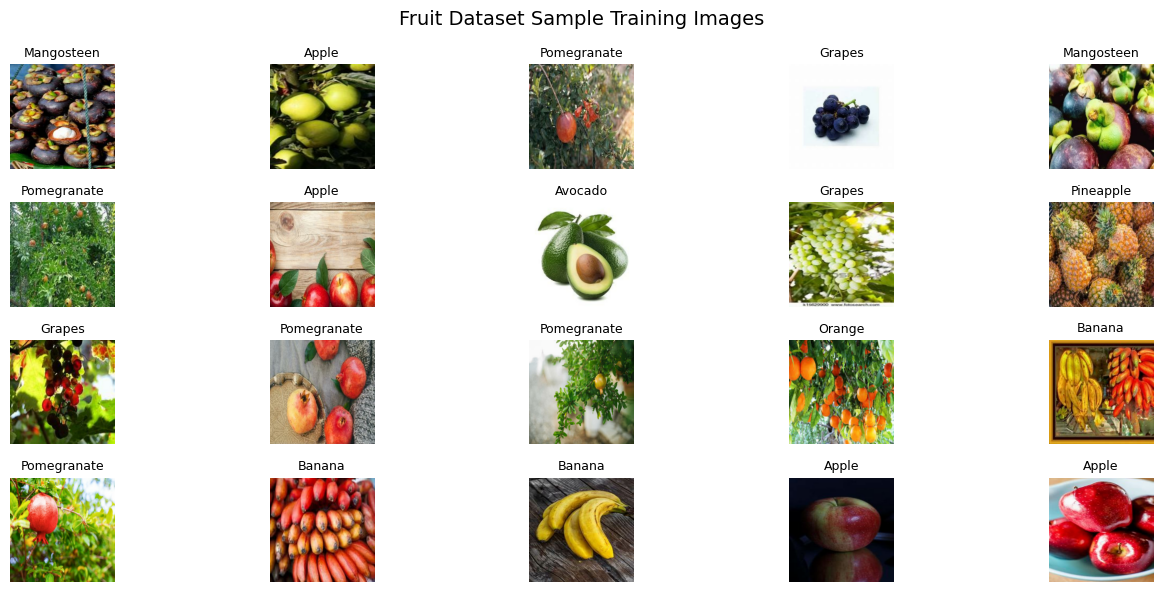

In [6]:
plt.figure(figsize=(14, 6))

for i in range(20):
    plt.subplot(4, 5, i + 1)
    plt.imshow(X_train[i].astype("uint8"))
    plt.title(class_names[np.argmax(y_train[i])], fontsize=9)
    plt.axis('off')

plt.suptitle('Fruit Dataset Sample Training Images', fontsize=14)
plt.tight_layout()
plt.show()

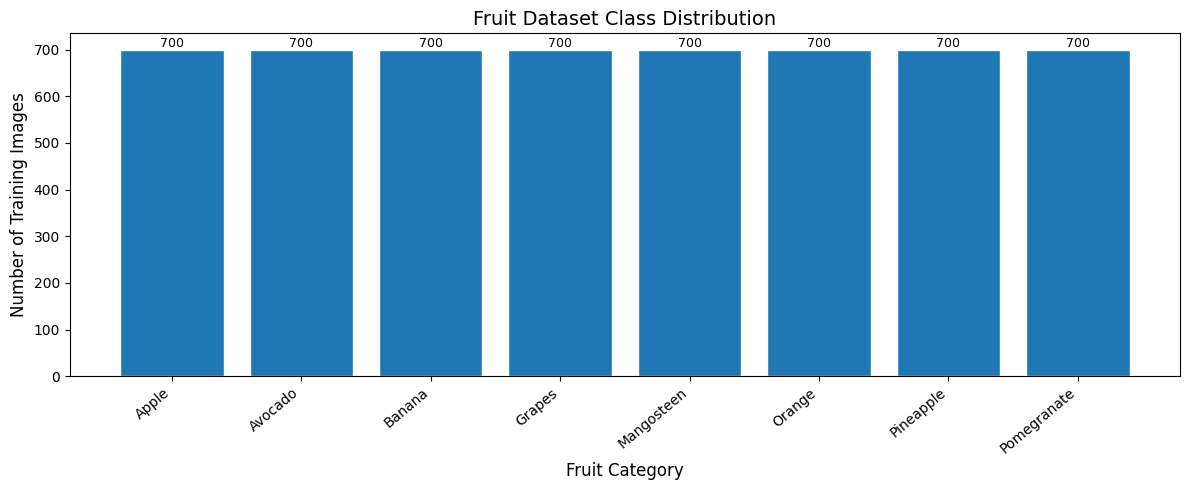


Images per class:
  Apple          : 700
  Avocado        : 700
  Banana         : 700
  Grapes         : 700
  Mangosteen     : 700
  Orange         : 700
  Pineapple      : 700
  Pomegranate    : 700


In [7]:
# Convert one-hot labels to class index
y_train_labels = np.argmax(y_train, axis=1)

unique, counts = np.unique(y_train_labels, return_counts=True)

plt.figure(figsize=(12, 5))
bars = plt.bar(class_names, counts, edgecolor='white')

plt.xlabel('Fruit Category', fontsize=12)
plt.ylabel('Number of Training Images', fontsize=12)
plt.title('Fruit Dataset Class Distribution', fontsize=14)
plt.xticks(rotation=40, ha='right')

# Add count labels
for bar, count in zip(bars, counts):
    plt.text(bar.get_x() + bar.get_width()/2,
             bar.get_height() + 5,
             str(count),
             ha='center',
             fontsize=9)

plt.tight_layout()
plt.show()

print('\nImages per class:')
for name, count in zip(class_names, counts):
    print(f'  {name:<14} : {count:,}')

In [8]:
AUTOTUNE = tf.data.AUTOTUNE

train_data = train_data.map(
    lambda x, y: (x / 255.0, y),
    num_parallel_calls=AUTOTUNE
).cache().prefetch(AUTOTUNE)

val_data = val_data.map(
    lambda x, y: (x / 255.0, y),
    num_parallel_calls=AUTOTUNE
).cache().prefetch(AUTOTUNE)

In [9]:
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
    layers.RandomContrast(0.1),
])

In [11]:
model = tf.keras.Sequential([
    data_augmentation,
    layers.Conv2D(32, (3,3), activation="relu",input_shape=(img_height, img_width, 3)),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(64, (3,3), activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Conv2D(128, (3,3), activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.MaxPooling2D(),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(128, activation="relu"),
    tf.keras.layers.BatchNormalization(),
    tf.keras.layers.Dropout(0.5),

    tf.keras.layers.Dense(len(class_names), activation="softmax")
])

In [12]:
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=3e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

In [13]:
callbacks = [
    tf.keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=10,
        restore_best_weights=True
    ),
    tf.keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.3,
        patience=4,
        min_lr=1e-6
    )
]

In [ ]:
history = model.fit(
    train_data,
    validation_data=val_data,
    epochs=100,
    callbacks=callbacks
)

In [ ]:
model.save("CNN_MODEL_FRUIT_CLASSIFICATION_002.h5")

In [ ]:
import json
with open("Trained_History_PROJECT_FRUIT_002.json",'w') as f:
    json.dump(history.history,f)

In [26]:
import json
with open("Trained_History_PROJECT_FRUIT_002.json", "r") as f:
    history = json.load(f)


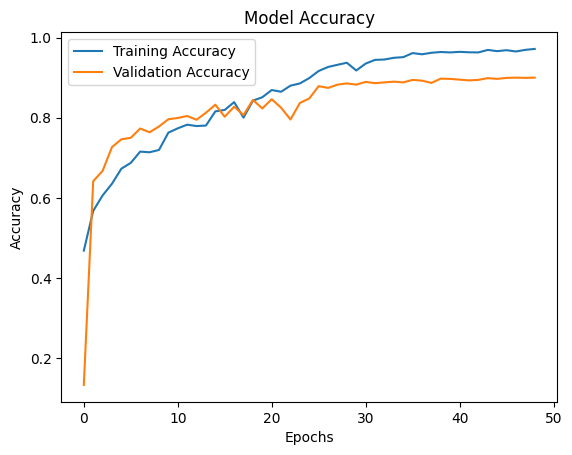

In [27]:
plt.plot(history['accuracy'], label='Training Accuracy')
plt.plot(history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.title('Model Accuracy')
plt.show()

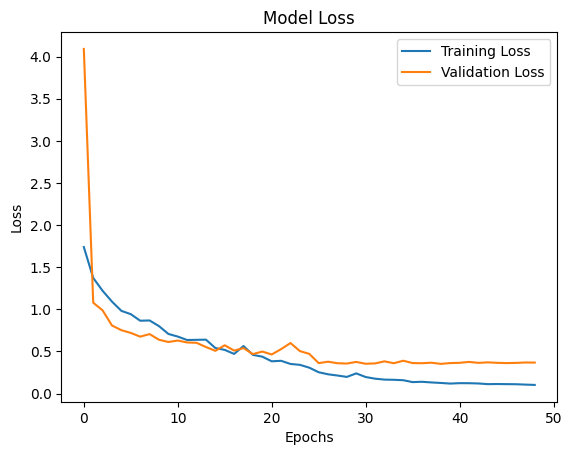

In [28]:
plt.plot(history['loss'], label='Training Loss')
plt.plot(history['val_loss'], label='Validation Loss')
plt.legend()
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Model Loss')
plt.show()

In [29]:
model = tf.keras.models.load_model("CNN_MODEL_FRUIT_CLASSIFICATION_002.h5")

In [30]:
test_data = tf.keras.preprocessing.image_dataset_from_directory(
    'Fruit1/test/',
    labels='inferred',
    label_mode='categorical',
    image_size=(224, 224),
    batch_size=8,
    shuffle=False
)
class_name=test_data.class_names

test_data = test_data.map(lambda x, y: (x/255.0, y))

Found 800 files belonging to 8 classes.


In [31]:
# Evaluate directly on dataset
test_loss, test_accuracy = model.evaluate(test_data, verbose=0)

print('=' * 55)
print('  FINAL TEST SET RESULTS')
print('=' * 55)
print(f'  Test Accuracy : {test_accuracy * 100:.2f}%')
print(f'  Test Loss     : {test_loss:.4f}')
print('=' * 55)

# Collect all true labels
y_true = np.concatenate([np.argmax(y.numpy(), axis=1) for x, y in test_data])

# Predict probabilities for all images
y_prob = model.predict(test_data, verbose=0)

# Predicted labels
y_pred = np.argmax(y_prob, axis=1)

idx = 0
print(f'\nExample Prediction (Test image {idx}):')
print(f'  True label  : {y_true[idx]} ({class_name[y_true[idx]]})')
print(f'  Predicted   : {y_pred[idx]} ({class_name[y_pred[idx]]})')
print(f'  Confidence  : {y_prob[idx][y_pred[idx]] * 100:.1f}%')

  FINAL TEST SET RESULTS
  Test Accuracy : 89.63%
  Test Loss     : 0.3979

Example Prediction (Test image 0):
  True label  : 0 (Apple)
  Predicted   : 0 (Apple)
  Confidence  : 99.7%


In [32]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
print('\nDetailed Classification Report')
print('=' * 70)
print(classification_report(
    y_true, y_pred,
    target_names=class_name,
    digits=3
))


Detailed Classification Report
              precision    recall  f1-score   support

       Apple      0.851     0.740     0.791       100
     Avocado      0.879     0.940     0.908       100
      Banana      0.907     0.880     0.893       100
      Grapes      0.918     0.890     0.904       100
  Mangosteen      0.903     0.930     0.916       100
      Orange      0.969     0.950     0.960       100
   Pineapple      0.905     0.950     0.927       100
 Pomegranate      0.840     0.890     0.864       100

    accuracy                          0.896       800
   macro avg      0.896     0.896     0.895       800
weighted avg      0.896     0.896     0.895       800



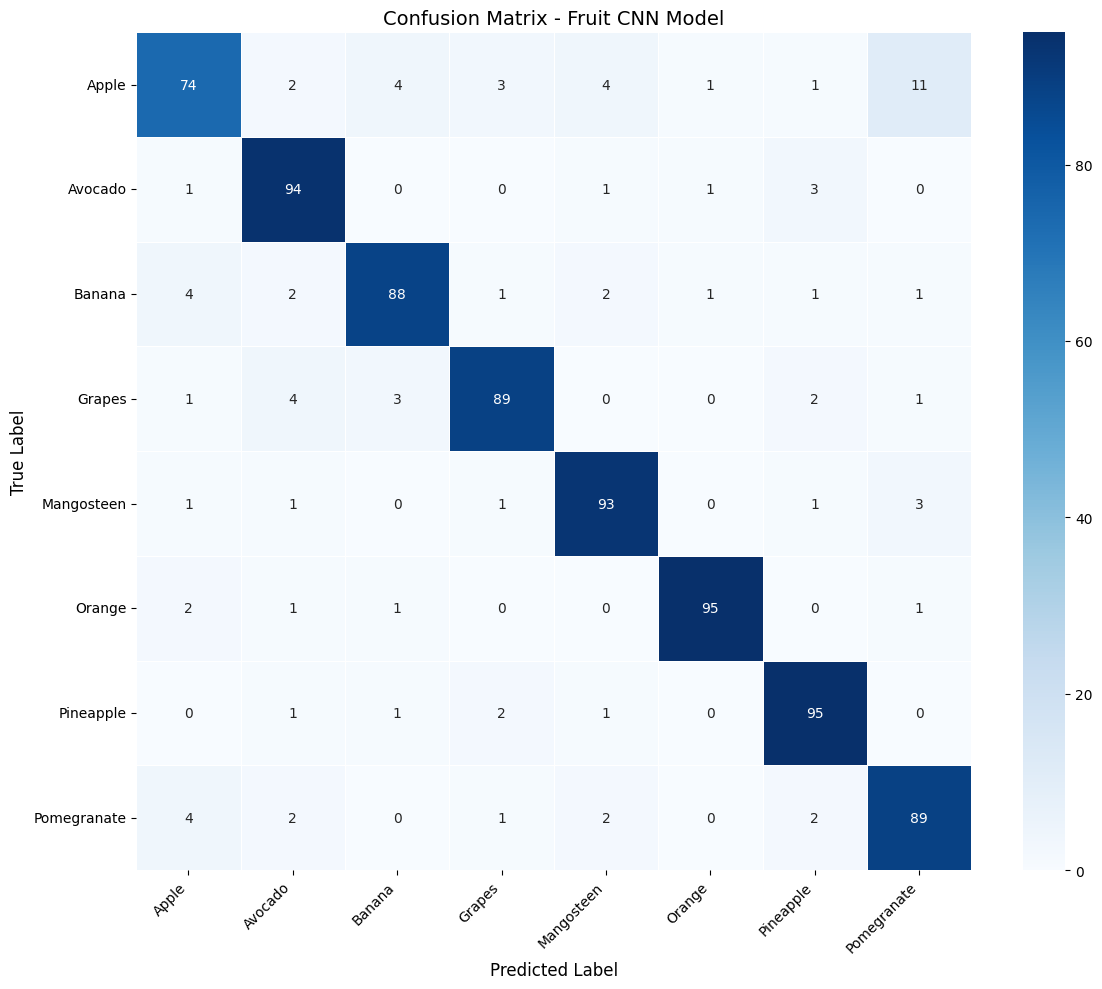

In [33]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(12, 10))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_name,
    yticklabels=class_name,
    linewidths=0.5
)

plt.xlabel('Predicted Label', fontsize=12)
plt.ylabel('True Label', fontsize=12)
plt.title('Confusion Matrix - Fruit CNN Model', fontsize=14)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [34]:
print('\nMost Common Misclassifications (> 10 occurrences):')
print('-' * 60)

num_classes = len(class_name)

for i in range(num_classes):
    for j in range(num_classes):
        if i != j and cm[i, j] > 10:   # threshold adjustable
            print(f'  {class_name[i]:<15} misclassified as '
                  f'{class_name[j]:<15} : {cm[i,j]} times')


Most Common Misclassifications (> 10 occurrences):
------------------------------------------------------------
  Apple           misclassified as Pomegranate     : 11 times


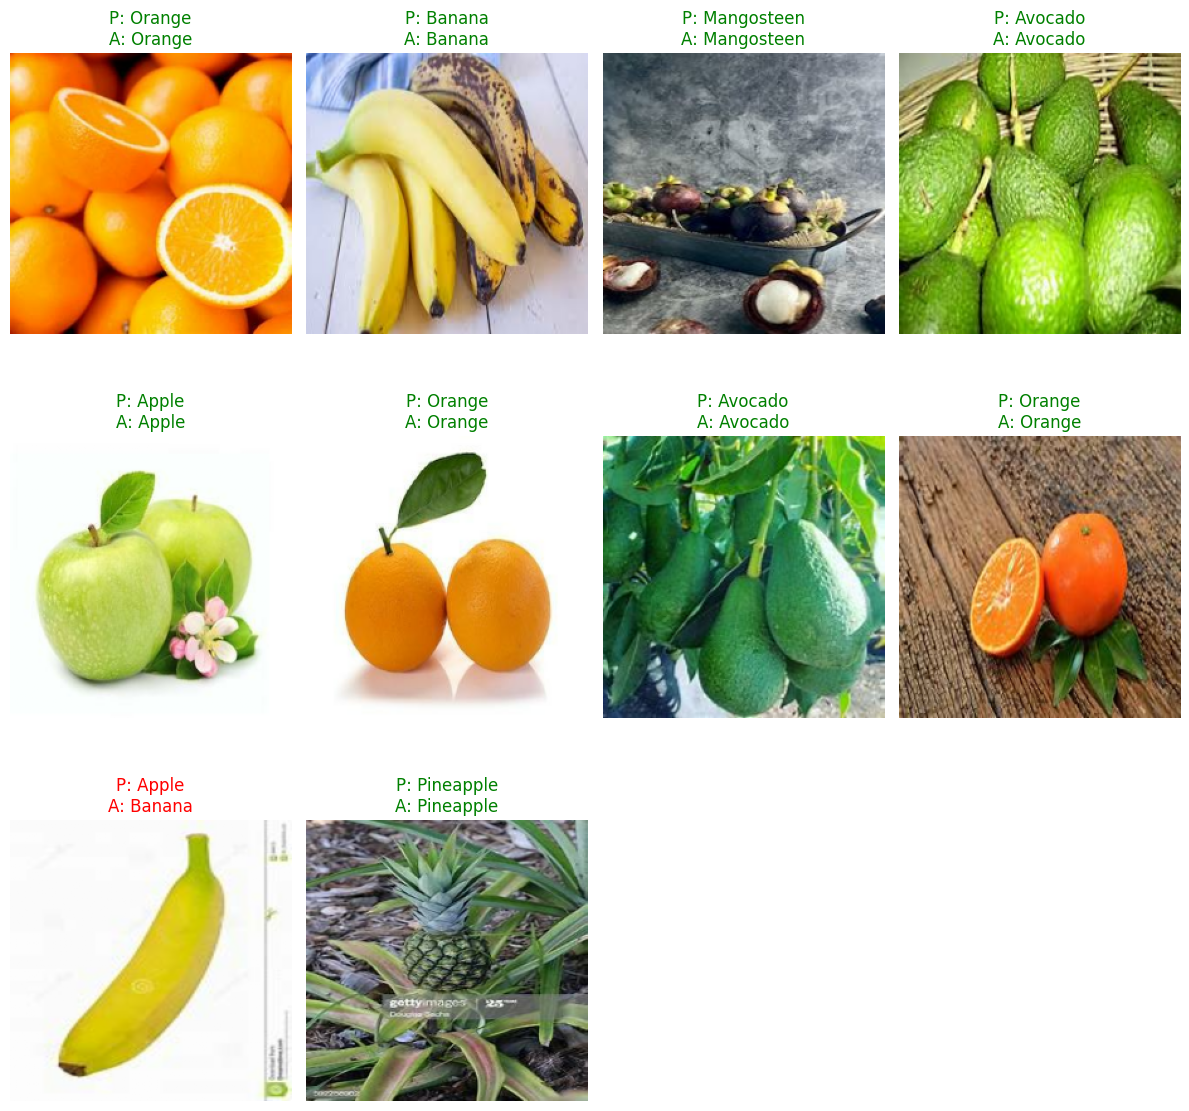

In [36]:
import matplotlib.pyplot as plt
import numpy as np
import random

# Collect all images and labels from dataset
all_images = []
all_labels = []

for images, labels in test_data:
    all_images.append(images.numpy())
    all_labels.append(labels.numpy())

# Convert list to numpy array
all_images = np.concatenate(all_images, axis=0)
all_labels = np.concatenate(all_labels, axis=0)

# Total number of images
total_images = len(all_images)

# Pick 10 random indices
random_indices = random.sample(range(total_images), 10)

plt.figure(figsize=(12,12))

for i, idx in enumerate(random_indices):

    image = all_images[idx]
    label = all_labels[idx]

    # Predict
    prediction = model.predict(np.expand_dims(image, axis=0), verbose=0)
    
    pred_index = np.argmax(prediction)
    true_index = np.argmax(label)

    pred_label = class_name[pred_index]
    true_label = class_name[true_index]

    color = "green" if pred_index == true_index else "red"

    plt.subplot(3,4,i+1)
    plt.imshow(image)
    plt.title(f"P: {pred_label}\nA: {true_label}", color=color)
    plt.axis("off")

plt.tight_layout()
plt.show()